**Mount Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Import Libraries**

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, LayerNormalization, Dropout, MultiHeadAttention
from tensorflow.keras.models import Model

from sklearn.metrics import mean_squared_error, mean_absolute_error

**Load Data**

In [3]:
BASE_PATH = "/content/drive/MyDrive/c01-price-forecasting/data/model_inputs/lstm/"

X_train = np.load(BASE_PATH + "X_train_seq.npy")
X_test = np.load(BASE_PATH + "X_test_seq.npy")
y_train = np.load(BASE_PATH + "y_train_seq.npy")
y_test = np.load(BASE_PATH + "y_test_seq.npy")

print("Loaded data for Transformer ✅")
print("Shape:", X_train.shape)

Loaded data for Transformer ✅
Shape: (1812, 8, 20)


**Build Transformer Block Encoder Function**

In [4]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):

    # Attention
    x = MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(inputs, inputs)
    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(x)

    # Feed Forward
    x_ff = Dense(ff_dim, activation="relu")(x)
    x_ff = Dense(inputs.shape[-1])(x_ff)
    x = x + x_ff
    x = LayerNormalization(epsilon=1e-6)(x)

    return x

**Build Transformer Model**

In [5]:
input_shape = X_train.shape[1:]

inputs = Input(shape=input_shape)

x = transformer_encoder(inputs, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)

x = tf.keras.layers.GlobalAveragePooling1D()(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.2)(x)

outputs = Dense(1)(x)

model = Model(inputs, outputs)

model.compile(optimizer="adam", loss="mse")

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 8, 20)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 8, 20)     │     21,268 │ input_layer[0][0… │
│ (MultiHeadAttentio… │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 8, 20)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 8, 20)     │         40 │ dropout_1[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8, 128)    │      2,688 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8, 20)     │      2,580 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 8, 20)     │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 20)     │         40 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 20)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      1,344 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 28,025 (109.47 KB)

 Trainable params: 28,025 (109.47 KB)

 Non-trainable params: 0 (0.00 B)

**Train Model**

In [6]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0663 - val_loss: 0.0301
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0108 - val_loss: 0.0066
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0072 - val_loss: 0.0069
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0058 - val_loss: 0.0074
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0059 - val_loss: 0.0064
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0049 - val_loss: 0.0086
Epoch 7/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0046 - val_loss: 0.0061
Epoch 8/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0043 - val_loss: 0.0122
Epoch 9/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0043 - val_loss: 0.0061
Epoch 10/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0040 - val_loss: 0.0154
Epoch 11/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0038 - val_loss: 0.0076
Epoch 12/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0

**Predictions**

In [7]:
y_pred = model.predict(X_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


**Inverse Scaling**

In [10]:
import joblib
import numpy as np

# Load scaler
scaler = joblib.load("/content/drive/MyDrive/c01-price-forecasting/data/model_inputs/lstm/scaler.pkl")

# Reconstruct shape
n_features = X_train.shape[2]

y_pred_full = np.zeros((len(y_pred), n_features + 1))
y_test_full = np.zeros((len(y_test), n_features + 1))

# Insert values
y_pred_full[:, -1] = y_pred.flatten()
y_test_full[:, -1] = y_test.flatten()

# Inverse transform
y_pred_inv = scaler.inverse_transform(y_pred_full)[:, -1]
y_test_inv = scaler.inverse_transform(y_test_full)[:, -1]

print("Inverse scaling completed ✅")

Inverse scaling completed ✅


In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100

print("\nCorrected LSTM Results:")
print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)


Corrected LSTM Results:
RMSE: 10.366057420192204
MAE: 8.524324093979823
MAPE: 6.900477324171585


**Evaluation**

In [8]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("\n📊 Transformer Results:")
print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)


📊 Transformer Results:
RMSE: 0.07931183948119516
MAE: 0.06522053629670868
MAPE: 9.868451088004143


**Plot**

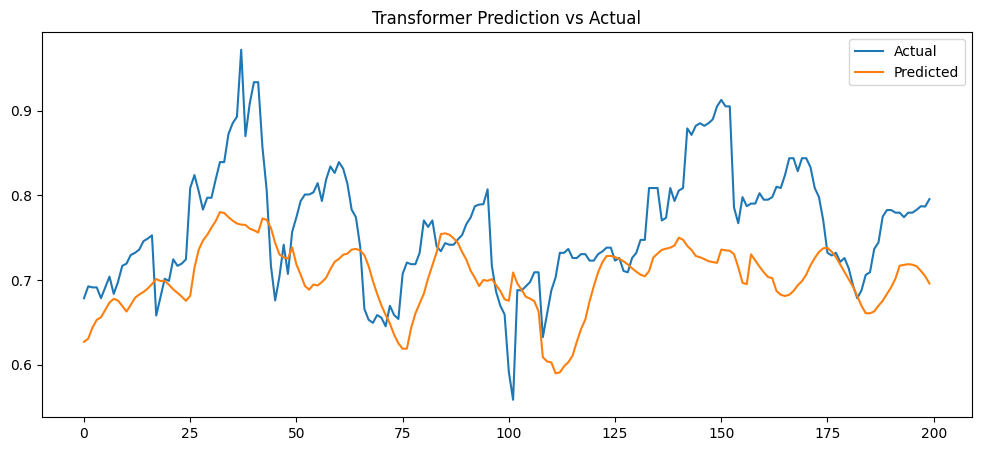

In [9]:
plt.figure(figsize=(12,5))

plt.plot(y_test[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")

plt.legend()
plt.title("Transformer Prediction vs Actual")
plt.show()